### Get the data

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
roboflow_key = user_secrets.get_secret("roboflow_key")

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=roboflow_key)
project = rf.workspace("dip-4gtfc").project("bangladeshi-street-food-dataset-qp9ne")
version = project.version(2)
dataset = version.download("voc")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, w


Extracting Dataset Version Zip to Bangladeshi-street-food-Dataset-2 in voc:: 100%|██████████| 19423/19423 [00:03<00:00, 6104.13it/s]


### Load libraries and define necessary things

In [3]:
from lxml import etree
from glob import glob
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as pt
import torch
import torchvision
import os
import json

In [4]:
train_transforms = T.Compose([
   T.RandomHorizontalFlip(0.5),
   T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
   T.ToTensor()
])

test_transforms = T.Compose([
   T.ToTensor()
])

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
torch.manual_seed(42)

classes = {
  'beguni': 0,
  'cha': 1,
  'chanachur': 2,
  'chotpoti': 3,
  'dim cake': 4,
  'fuska': 5,
  'jhalmuri': 6,
  'jilapi': 7,
  'kulfi': 8,
  'murobba': 9,
  'papar': 10,
  'peyaju': 11,
  'puri': 12,
  'singara': 13,
  'tiler khaja': 14
}

In [5]:
def visualize(img, target, ax, threshold=0.5):
   colors = [
       "red", "green", "blue", "yellow", "magenta", "skyblue", "black", "orange",
       "purple", "cyan", "lime", "pink", "brown", "teal", "navy", "gold"
   ]
   img = img.permute(1, 2, 0)
   ax.imshow(img.cpu().numpy())

   labels = target["labels"].cpu()
   boxes = target["boxes"].cpu()
   scores = target["scores"].cpu()

   for i in range(len(labels)):
      score = scores[i].item()
      label_id = labels[i].item()

      if score > threshold and label_id != 0:
        pred_label = list(classes.keys())[label_id - 1]
        x1, y1, x2, y2 = boxes[i]

        rect = pt.Rectangle(
          (x1, y1),
          x2 - x1,
          y2 - y1,
          facecolor="none",
          edgecolor=colors[label_id]
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 20, f'{pred_label} ({score:.2f})', color=colors[label_id], fontsize=8, bbox=dict(facecolor='white', alpha=0.7))

### Build Dataset

In [6]:
class FoodDetectionDataset(Dataset):
   def __init__(self, root: str, split: str, transforms: torchvision.transforms):
      self.root = root
      self.split = split
      self.transforms = transforms
      self.annots = glob(f"{root}/{split}/**/*.xml", recursive=True)

   def _extract_data(self, xml_file: str):
      """
      Read the xml file and return the metadata
      """
      tree = etree.parse(xml_file)
      root = tree.getroot()

      img_path = root.find("filename").text

      # image size
      size = root.find("size")
      width = int(size.find("width").text)
      height = int(size.find("height").text)

      boxes = []
      labels = []

      for obj in root.findall("object"):
          class_name = obj.find("name").text
          bndbox = obj.find("bndbox")

          xmin = int(bndbox.find("xmin").text)
          ymin = int(bndbox.find("ymin").text)
          xmax = int(bndbox.find("xmax").text)
          ymax = int(bndbox.find("ymax").text)

          labels.append(class_name)
          boxes.append([xmin, ymin, xmax, ymax])

      return img_path, width, height, boxes, labels


   def __len__(self):
      return len(self.annots)

   def __getitem__(self, idx):
      annot = self.annots[idx]
      img_path, width, height, boxes, labels = self._extract_data(annot)
      labels = list(map(lambda x: classes[x]+1, labels)) # get the value of the class

      image = Image.open(os.path.join(self.root, self.split, img_path))
      image = self.transforms(image)

      if self.split == "valid":
         return image, img_path, width, height, [(x1, y1, x2-x1, y2-y1) for x1, y1, x2, y2 in boxes], labels

      return image, {
        "boxes": torch.tensor(boxes).reshape(-1, 4),
        "labels": torch.tensor(labels).type(torch.int64)
      }

In [7]:
train_data = FoodDetectionDataset("Bangladeshi-street-food-Dataset-2", "train", train_transforms)

val_data = FoodDetectionDataset("Bangladeshi-street-food-Dataset-2", "valid", test_transforms)
test_data = FoodDetectionDataset("Bangladeshi-street-food-Dataset-2", "test", test_transforms)

#### Write the GT Json file in coco format for evaluation

In [8]:
def write_coco_json(data, file_path):
  # build coco format json gt
  coco_json = {
      "images": [],
      "annotations": [],
      "categories": []
  }

  # Populate categories
  for class_name, class_id in classes.items():
      coco_json['categories'].append({
          'id': class_id + 1, # +1 to match labels from FoodDetectionDataset
          'name': class_name,
          'supercategory': ''
      })

  image_id_counter = 0
  annotation_id_counter = 0

  for i in range(len(data)):
     _, img_path, width, height, boxes, labels = data[i]

     image_id_counter += 1
     image_info = {
         'id': image_id_counter,
         'file_name': img_path,
         'width': width,
         'height': height
     }
     coco_json['images'].append(image_info)

     for box, label in zip(boxes, labels):
         annotation_id_counter += 1
         x, y, w, h = box
         area = w * h

         annotation_info = {
             'id': annotation_id_counter,
             'image_id': image_id_counter,
             'category_id': label,
             'bbox': list(box), # ensure it's a list
             'area': area,
             'iscrowd': 0
         }
         coco_json['annotations'].append(annotation_info)

  with open(file_path, "w") as f:
     json.dump(coco_json, f)

In [9]:
write_coco_json(val_data, "val_coco.json")

### Define the model

In [10]:
model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT").to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 214MB/s]


In [11]:
# Get the number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# Define the number of classes
num_classes = len(classes) + 1
# Replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes).to(device)

### Train the model

In [12]:
def train_model(model, train_data, batch, epochs, lr, verbose = 0):
  """
  Define the DataLoader from the train data then train the model with defined epochs, batch size, learning rate
  if verbose = 1 , show loss on every epoch
  """

  train_loader = DataLoader(
    train_data,
    batch_size=batch,
    pin_memory=True,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
  )
  optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=0.0009, momentum=0.8)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

  model.train()
  for epoch in range(epochs):
    total_loss = 0
    for imgs, targets in tqdm(train_loader, desc=f"Epoch: {epoch+1}/{epochs}"):
       imgs = [img.to(device, non_blocking=True) for img in imgs]
       targets = [{k: v.to(device, non_blocking=True) for k, v in t.items() } for t in targets]
       loss_dict = model(imgs, targets)
       losses = sum(loss_dict.values())

       # steps
       optimizer.zero_grad()
       losses.backward()
       optimizer.step()

       total_loss += losses

    if (verbose == 1) or ((epochs % verbose) == 0):
       print(f"Epoch: {epoch+1} - Loss: {total_loss/len(train_loader)}")

In [13]:
train_model(
    model,
    train_data,
    batch=12,
    epochs=40,
    lr=5e-4,
    verbose=1
)

Epoch: 1/40: 100%|██████████| 701/701 [04:40<00:00,  2.50it/s]


Epoch: 1 - Loss: 1.0496330261230469


Epoch: 2/40: 100%|██████████| 701/701 [04:36<00:00,  2.54it/s]


Epoch: 2 - Loss: 0.8492199182510376


Epoch: 3/40: 100%|██████████| 701/701 [04:40<00:00,  2.50it/s]


...

Epoch: 38 - Loss: 0.5672851800918579


Epoch: 39/40: 100%|██████████| 701/701 [04:25<00:00,  2.64it/s]


Epoch: 39 - Loss: 0.5640562772750854


Epoch: 40/40: 100%|██████████| 701/701 [04:23<00:00,  2.66it/s]


Epoch: 40 - Loss: 0.5669581890106201


### Validate the model

In [14]:
def validate_model(model, val_data, gt_json):
  """
  Collect model's prediction and save it as pred.json after preprocessing
  Evaluate the model with gt_file
  """
  predictions = []
  model.eval()
  with torch.no_grad():
    # The image_id in val_coco.json starts from 1 and increments for each image.
    # So, we track it similarly here.
    image_id_counter = 0

    for idx in tqdm(range(len(val_data)), desc="Validating model"):
       img, _, _, _, _, _ = val_data[idx]

       image_id_counter += 1
       preds = model(img.unsqueeze(0).to(device, non_blocking=True))

       if preds and len(preds[0]['boxes']) > 0: # Ensure there are detections
           pred = preds[0] # Get the predictions for the current image

           boxes = pred['boxes'].cpu().numpy()
           labels = pred['labels'].cpu().numpy()
           scores = pred['scores'].cpu().numpy()

           for box, label, score in zip(boxes, labels, scores):
               if score < 0.01: # skip too low scores entry
                  continue

               # COCO format for bbox: [x, y, width, height]
               x1, y1, x2, y2 = box
               coco_bbox = [float(x1), float(y1), float(x2-x1), float(y2-y1)]

               predictions.append({
                   "image_id": image_id_counter,
                   "category_id": int(label), # labels are already +1 from `classes` in FoodDetectionDataset
                   "bbox": coco_bbox,
                   "score": float(score)
               })

  # Save predictions to JSON file
  with open("preds.json", "w") as f:
      json.dump(predictions, f)

  # Evaluate using pycocotools
  print("Starting COCO evaluation...")
  coco_gt = COCO(gt_json)
  coco_dt = coco_gt.loadRes("preds.json")

  coco_eval = COCOeval(coco_gt, coco_dt, 'bbox') # 'bbox' is the task type
  coco_eval.evaluate()
  coco_eval.accumulate()
  coco_eval.summarize()
  print("COCO evaluation complete.")

In [15]:
validate_model(model, val_data, "val_coco.json")

Validating model: 100%|██████████| 748/748 [00:18<00:00, 39.95it/s]


Starting COCO evaluation...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.10s).
Accumulating evaluation results...
DONE (t=0.19s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.496
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.763
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.549
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.401
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.532
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.408
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.597
 Average Recall     (AR) @[ IoU=0.50:

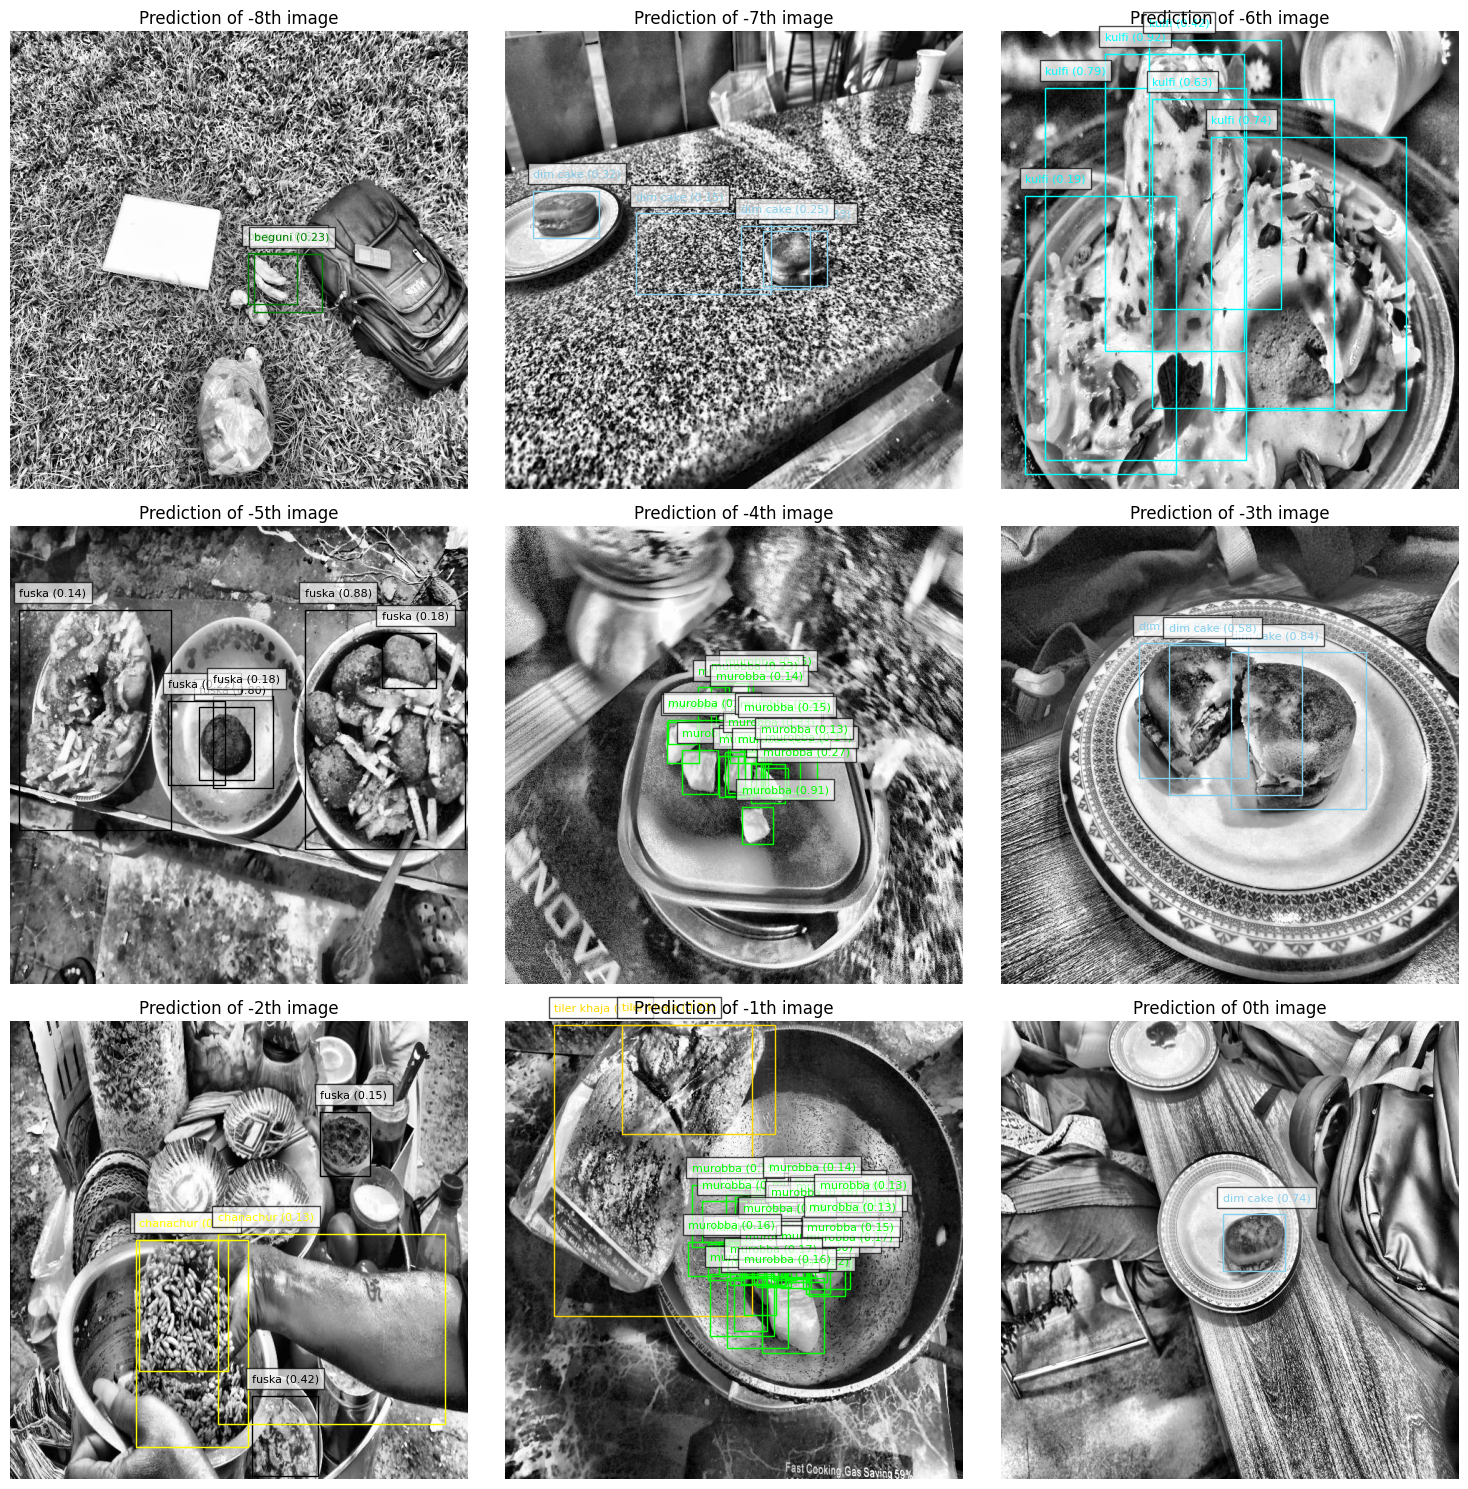

In [16]:
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i in range(-9, 0):
   img, _ = test_data[i]
   img_tensor = img.unsqueeze(0).to(device, non_blocking=True)

   with torch.no_grad():
      preds = model(img_tensor)

   visualize(img, preds[0], axes[i], threshold=0.13)
   axes[i].set_title(f"Prediction of {i+1}th image")
   axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
!rm -rf Bangladeshi-street-food-Dataset-2